In [1]:
# pip install flwr

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Input: 3 x 228 x 228
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # After Pool 1: 32 x 114 x 114
        # After Pool 2: 64 x 57 x 57
        
        # This layer ensures that no matter the input, the output to 
        # the FC layer is always 64 * 8 * 8
        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        # Layer 1: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv1(x)))
        
        # Layer 2: Conv -> ReLU -> Pool
        x = self.pool(F.relu(self.conv2(x)))
        
        # Bridge: Forces spatial dimensions to 8x8
        x = self.adaptive_pool(x)
        
        # Flatten and Fully Connected
        x = torch.flatten(x, 1) 
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# # Quick verification
# model = SimpleCNN(num_classes=10)
# sample_input = torch.randn(1, 3, 228, 228)
# output = model(sample_input)
# print(f"Output shape: {output.shape}") # Should be [1, 10]

In [30]:
def train(model, loader, optimizer, criterion, device, epochs=1):
    model.train()
    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()


def test(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total


In [31]:
import flwr as fl
import numpy as np

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, model, trainloader, testloader, device):
        self.model = model
        self.trainloader = trainloader
        self.testloader = testloader
        self.device = device
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)

    def get_parameters(self, config=None):
        return [val.cpu().numpy() for val in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        params_dict = zip(self.model.state_dict().keys(), parameters)
        state_dict = {k: torch.tensor(v) for k, v in params_dict}
        self.model.load_state_dict(state_dict, strict=True)

    def fit(self, parameters, config=None):
        self.set_parameters(parameters)
        train(self.model, self.trainloader, self.optimizer,
              self.criterion, self.device, epochs=1)
        return self.get_parameters(), len(self.trainloader.dataset), {}

    def evaluate(self, parameters, config=None):
        self.set_parameters(parameters)
        acc = test(self.model, self.testloader, self.device)
        return float(1 - acc), len(self.testloader.dataset), {"accuracy": acc}


In [32]:
def load_datasets():

    DATA_ROOT = r"C:\Users\VARAD\OneDrive\Desktop\AIML-Project\END-END-ML\archive"

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    train_dataset = datasets.ImageFolder(
        root=f"{DATA_ROOT}/train",
        transform=transform
    )

    test_dataset = datasets.ImageFolder(
        root=f"{DATA_ROOT}/val",
        transform=transform
    )

    num_clients = 3
    total_len = len(train_dataset)
    base_len = total_len // num_clients
    remainder = total_len % num_clients

    lengths = [base_len] * num_clients
    lengths[0] += remainder   # absorb leftovers safely

    client_datasets = random_split(train_dataset, lengths)
    print(len(train_dataset.classes) )


    return client_datasets, test_dataset





In [43]:
# Client Generator

def client_fn(cid):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    client_datasets, testset = load_datasets()

    trainloader = DataLoader(client_datasets[int(cid)],
                             batch_size=64, shuffle=True)
    testloader = DataLoader(testset, batch_size=64)

    model = SimpleCNN(num_classes=38).to(device)

    return FlowerClient(model, trainloader, testloader, device)


In [3]:
# Federated Simulation (FedAvg)

# if __name__ == "__main__":
#     fl.simulation.start_simulation(
#         client_fn=client_fn,
#         num_clients=3,
#         config=fl.server.ServerConfig(num_rounds=5),
#         strategy=fl.server.strategy.FedAvg()
#     )


In [1]:
# torch.save(model.state_dict(), "federated_model.pth")
# print("model saved")


In [11]:
model = SimpleCNN(num_classes=38)
path=r"C:\Users\VARAD\OneDrive\Desktop\AIML-Project\END-END-ML\archive\federated_model_38.pth"
model.load_state_dict(torch.load(path))
model.eval()


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=38, bias=True)
)

In [12]:
print(model.fc2.weight.shape)


torch.Size([38, 128])


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report


In [44]:
import torch

device = torch.device("cuda")  # force GPU
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))


Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [47]:
model = SimpleCNN(num_classes=38)
model.load_state_dict(
    torch.load(r"C:\Users\VARAD\OneDrive\Desktop\AIML-Project\END-END-ML\archive\federated_model_38.pth", map_location="cuda")
)
model.to(device)
model.eval()


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=38, bias=True)
)

In [48]:
DATA_ROOT = r"C:\Users\VARAD\OneDrive\Desktop\AIML-Project\END-END-ML\archive"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

test_dataset = datasets.ImageFolder(
    root=f"{DATA_ROOT}/val",
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

class_names = test_dataset.classes
num_classes = len(class_names)

print("Classes:", num_classes)


Classes: 38


In [49]:
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"\n✅ Overall Accuracy: {accuracy * 100:.2f}%")



✅ Overall Accuracy: 77.93%


In [50]:
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix:")
print(cm)



Confusion Matrix:
[[  84    1    1 ...    2    0    0]
 [   2   84    0 ...    1    0    0]
 [   3    2    1 ...    3    0    0]
 ...
 [   1    1    0 ... 1034    0    0]
 [   0    0    0 ...    8   56    0]
 [   0    0    0 ...    1    0  285]]


In [51]:
TP = np.diag(cm)
FP = cm.sum(axis=0) - TP
FN = cm.sum(axis=1) - TP
TN = cm.sum() - (TP + FP + FN)

print("\nPer-class statistics:")
for i, cls in enumerate(class_names):
    print(f"{cls:20s} | TP: {TP[i]:4d}  FP: {FP[i]:4d}  FN: {FN[i]:4d}  TN: {TN[i]:6d}")



Per-class statistics:
Apple___Apple_scab   | TP:   84  FP:   44  FN:   42  TN:  10706
Apple___Black_rot    | TP:   84  FP:   32  FN:   41  TN:  10719
Apple___Cedar_apple_rust | TP:    1  FP:    7  FN:   54  TN:  10814
Apple___healthy      | TP:  212  FP:   67  FN:  117  TN:  10480
Blueberry___healthy  | TP:  259  FP:   53  FN:   42  TN:  10522
Cherry_(including_sour)___Powdery_mildew | TP:  170  FP:   72  FN:   41  TN:  10593
Cherry_(including_sour)___healthy | TP:  106  FP:   25  FN:   65  TN:  10680
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | TP:   29  FP:   12  FN:   74  TN:  10761
Corn_(maize)___Common_rust_ | TP:  216  FP:   66  FN:   23  TN:  10571
Corn_(maize)___Northern_Leaf_Blight | TP:  170  FP:  115  FN:   27  TN:  10564
Corn_(maize)___healthy | TP:  233  FP:    9  FN:    0  TN:  10634
Grape___Black_rot    | TP:  171  FP:   35  FN:   65  TN:  10605
Grape___Esca_(Black_Measles) | TP:  248  FP:   44  FN:   29  TN:  10555
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) | T

In [52]:
print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
))



Classification Report:
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.6562    0.6667    0.6614       126
                                 Apple___Black_rot     0.7241    0.6720    0.6971       125
                          Apple___Cedar_apple_rust     0.1250    0.0182    0.0317        55
                                   Apple___healthy     0.7599    0.6444    0.6974       329
                               Blueberry___healthy     0.8301    0.8605    0.8450       301
          Cherry_(including_sour)___Powdery_mildew     0.7025    0.8057    0.7506       211
                 Cherry_(including_sour)___healthy     0.8092    0.6199    0.7020       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7073    0.2816    0.4028       103
                       Corn_(maize)___Common_rust_     0.7660    0.9038    0.8292       239
               Corn_(maize)___Northern_Leaf_Blight     

In [62]:
import random
import matplotlib.pyplot as plt
import torch

def visualize_predictions(model, dataset, class_names, device, num_images=5):
    model.eval()
    indices = random.sample(range(len(dataset)), num_images)

    plt.figure(figsize=(3 * num_images, 4))

    def short(name, max_len=15):
        return name if len(name) <= max_len else name[:12] + "..."

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = dataset[idx]
            image_input = image.unsqueeze(0).to(device)

            output = model(image_input)
            pred = output.argmax(dim=1).item()

            img = image.permute(1, 2, 0).cpu().numpy()

            plt.subplot(1, num_images, i + 1)
            plt.imshow(img)

            plt.title(
                f"P: {short(class_names[pred])}\n"
                f"T: {short(class_names[label])}",
                fontsize=9,
                pad=8
            )

            plt.axis("off")

    plt.subplots_adjust(wspace=0.6)
    plt.show()


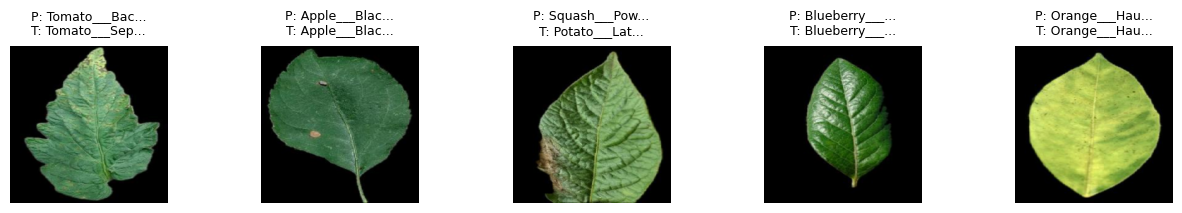

In [63]:
visualize_predictions(
    model,
    test_dataset,
    class_names,
    device,
    num_images=5
)
